
# **Stroke Prediction Dataset**

Importovanie potrebných knižníc pre prácu s datasetom

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ace_tools_open as tools
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **Popis dát**
Odkaz na Stroke Prediction Dataset: [Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

---

| **Atribút** | **Popis** |
|:-----------|:----------|
| **id** | Jedinečný identifikátor pacienta. |
| **gender** | Pohlavie pacienta (Male, Female, Other). |
| **age** | Vek pacienta v rokoch. |
| **hypertension** | Informácia, či má pacient vysoký krvný tlak (0 = nie, 1 = áno). |
| **heart_disease** | Informácia, či trpí pacient srdcovým ochorením (0 = nie, 1 = áno). |
| **ever_married** | Informácia, či bol/bola pacient(ka) niekedy ženatý/vydatá (Yes/No). |
| **work_type** | Typ zamestnania pacienta (Private, Self-employed, Govt_job, children, Never_worked). |
| **Residence_type** | Typ miesta pobytu (Urban alebo Rural). |
| **avg_glucose_level** | Priemerná hladina glukózy v krvi. |
| **bmi** | Body Mass Index – index telesnej hmotnosti. |
| **smoking_status** | Stav fajčenia (formerly smoked, never smoked, smokes, Unknown). |
| **stroke** | Cieľová premenná – či pacient mal mozgovú príhodu (0 = nie, 1 = áno). |



# **Načítanie Stroke Prediction Datasetu**

In [78]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv", delimiter=",")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


**Zistenie dátových typov v datasete a kontrola, či sa tam nenachádzajú NaN hodnoty.**



In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [80]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Pomocou df.info() sme zistili, že nie všetky atribúty majú číselný typ a v datasete sa nachádzajú aj kategorické dáta. Taktiež sme zistili, že dataset obsahuje hodnoty null, takže ich bude potrebné ošetriť.

In [81]:
print("Počet riadkov     : ", df.shape[0])
print("Počet stĺpcov     : ", df.shape[1])

print("\nPremenné (stĺpce) :\n", df.columns.tolist())

print("\nPočet chýbajúcich hodnôt : ", df.isnull().sum().values.sum())

print("\nPočet unikátnych hodnôt v každej premennej:\n", df.nunique())


Počet riadkov     :  5110
Počet stĺpcov     :  12

Premenné (stĺpce) :
 ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Počet chýbajúcich hodnôt :  201

Počet unikátnych hodnôt v každej premennej:
 id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64


**Základné štatistické charakteristiky dát v datasete a identifikácia rozsahov hodnôt jednotlivých atribútov.**


In [82]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


# **Vizualizácia dát**

Na základe predošlej analýzy datasetu sme zistili, že nie všetky atribúty spadajú do numerickej kategórie, a tak ich nemôžeme všetky vizualizovať pomocou histogramov ale kategorické musíme osobitne.



**Vizualizácia kategorických dát**


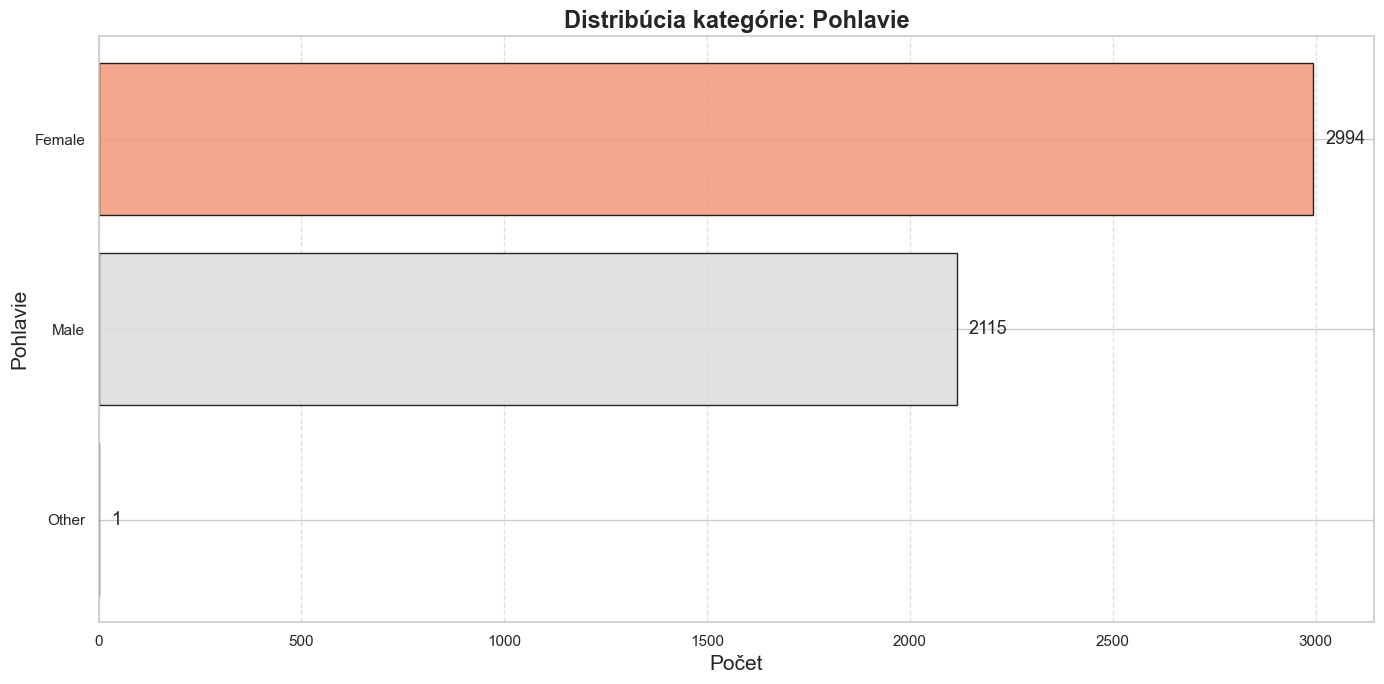

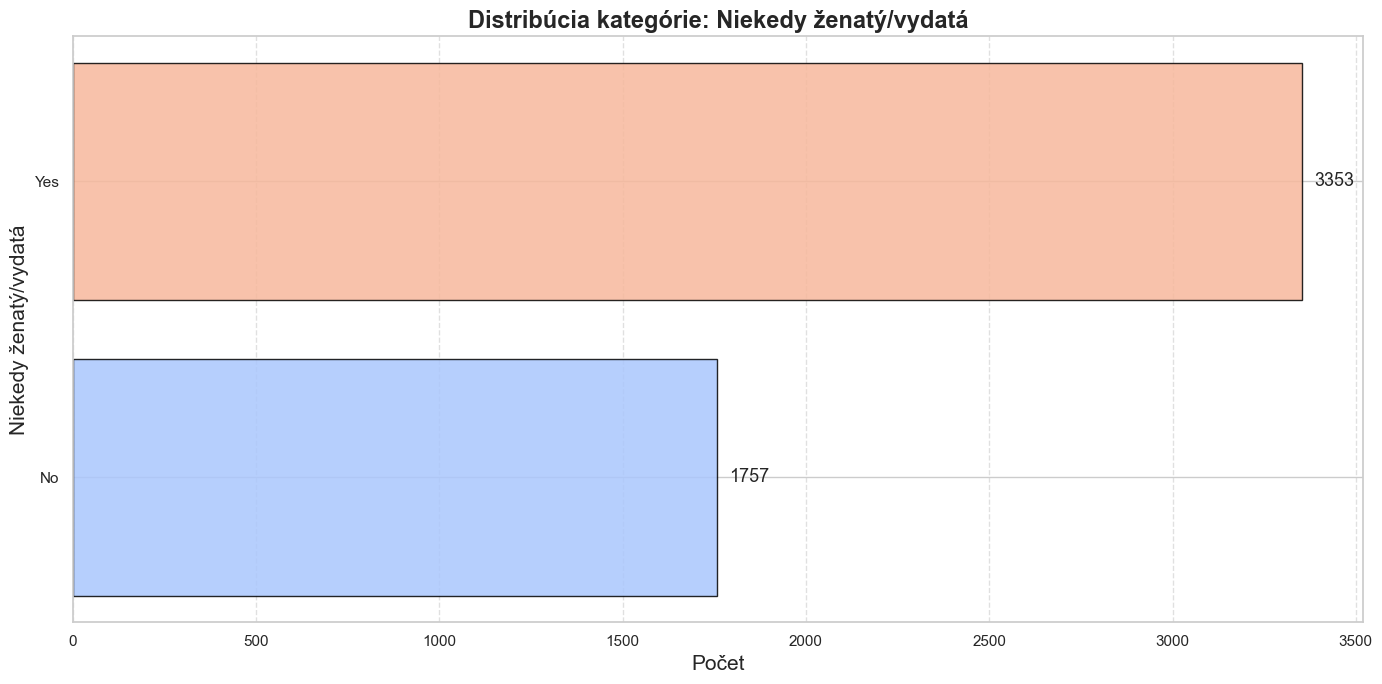

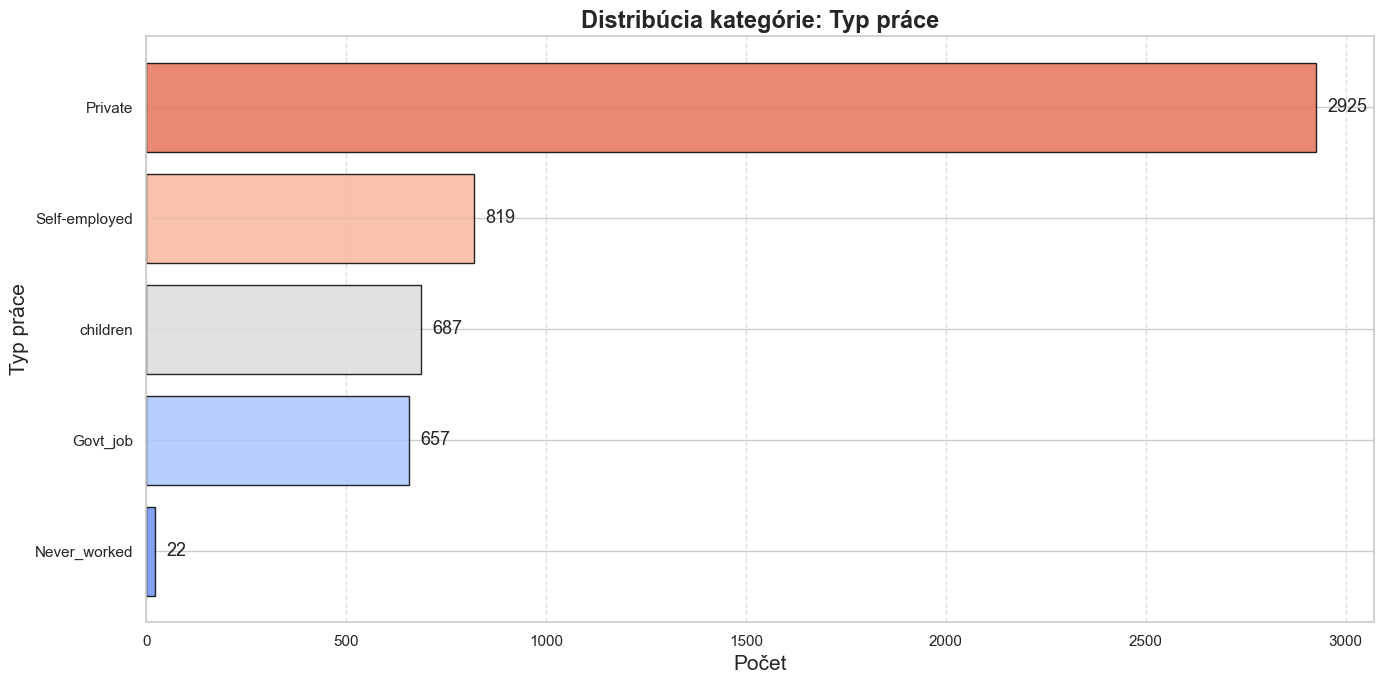

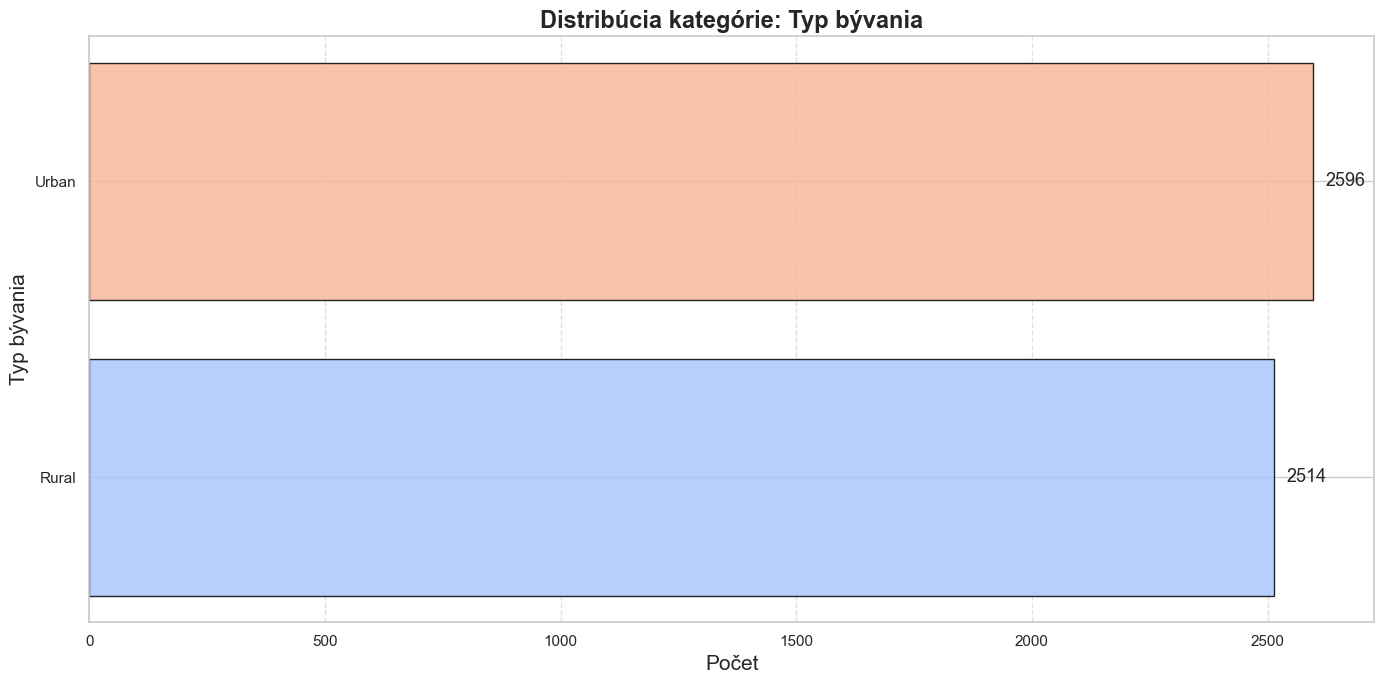

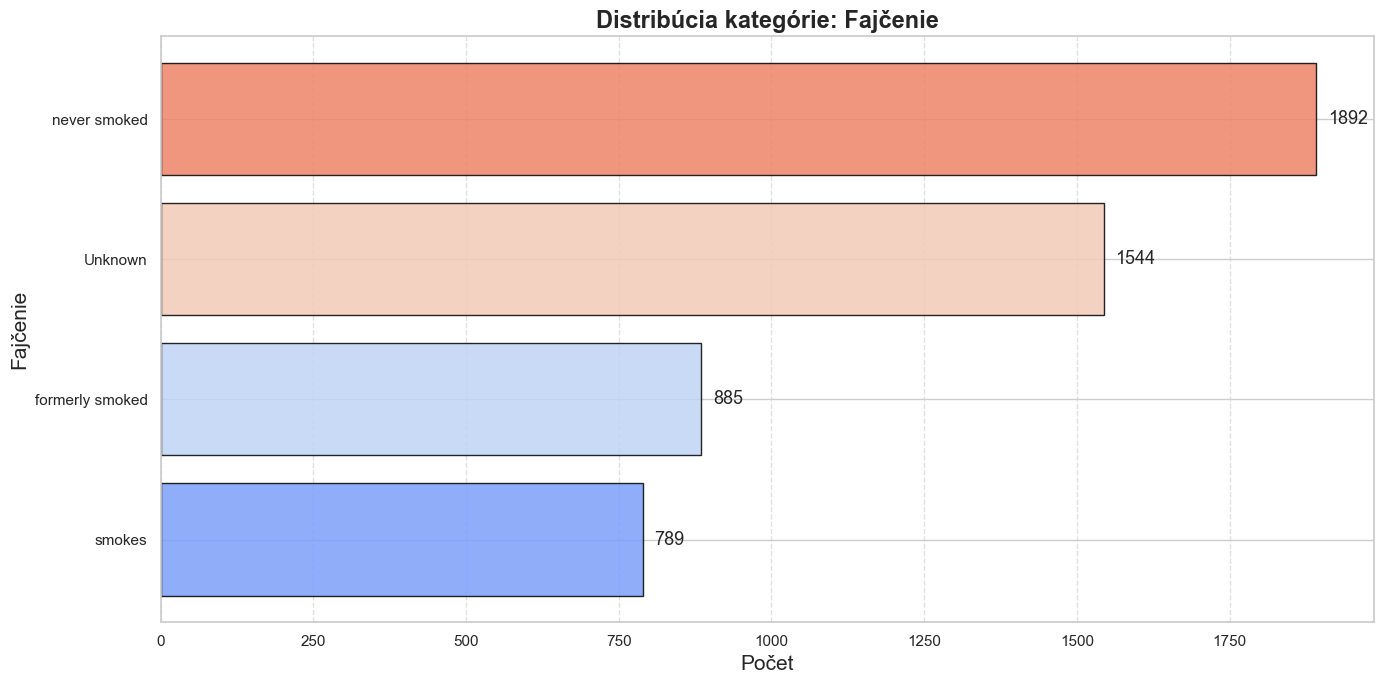

In [83]:
sns.set_theme(style="whitegrid")

categorical_cols = [
    'gender',  
    'ever_married', 'work_type', 'Residence_type',
    'smoking_status', 
]

slovenske_nazvy = {
    'gender': 'Pohlavie',
    'heart_disease': 'Srdcové ochorenie',
    'ever_married': 'Niekedy ženatý/vydatá',
    'work_type': 'Typ práce',
    'Residence_type': 'Typ bývania',
    'smoking_status': 'Fajčenie',
}

for col in categorical_cols:
    counts = df[col].value_counts().sort_values()

    plt.figure(figsize=(14, 7))
    
    bars = plt.barh(
        counts.index.astype(str),
        counts.values,
        color=sns.color_palette("coolwarm", n_colors=len(counts)),
        edgecolor='black',
        alpha=0.85
    )

    y_label = slovenske_nazvy.get(col, col)

    plt.xlabel('Počet', fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.title(f'Distribúcia kategórie: {y_label}', fontsize=17, fontweight='bold')

    plt.grid(axis='x', linestyle='--', alpha=0.6)

    for bar in bars:
        plt.text(
            bar.get_width() + max(counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width())}',
            va='center',
            fontsize=13
        )

    plt.tight_layout()
    plt.show()


**Vizualizácia numerických dát**

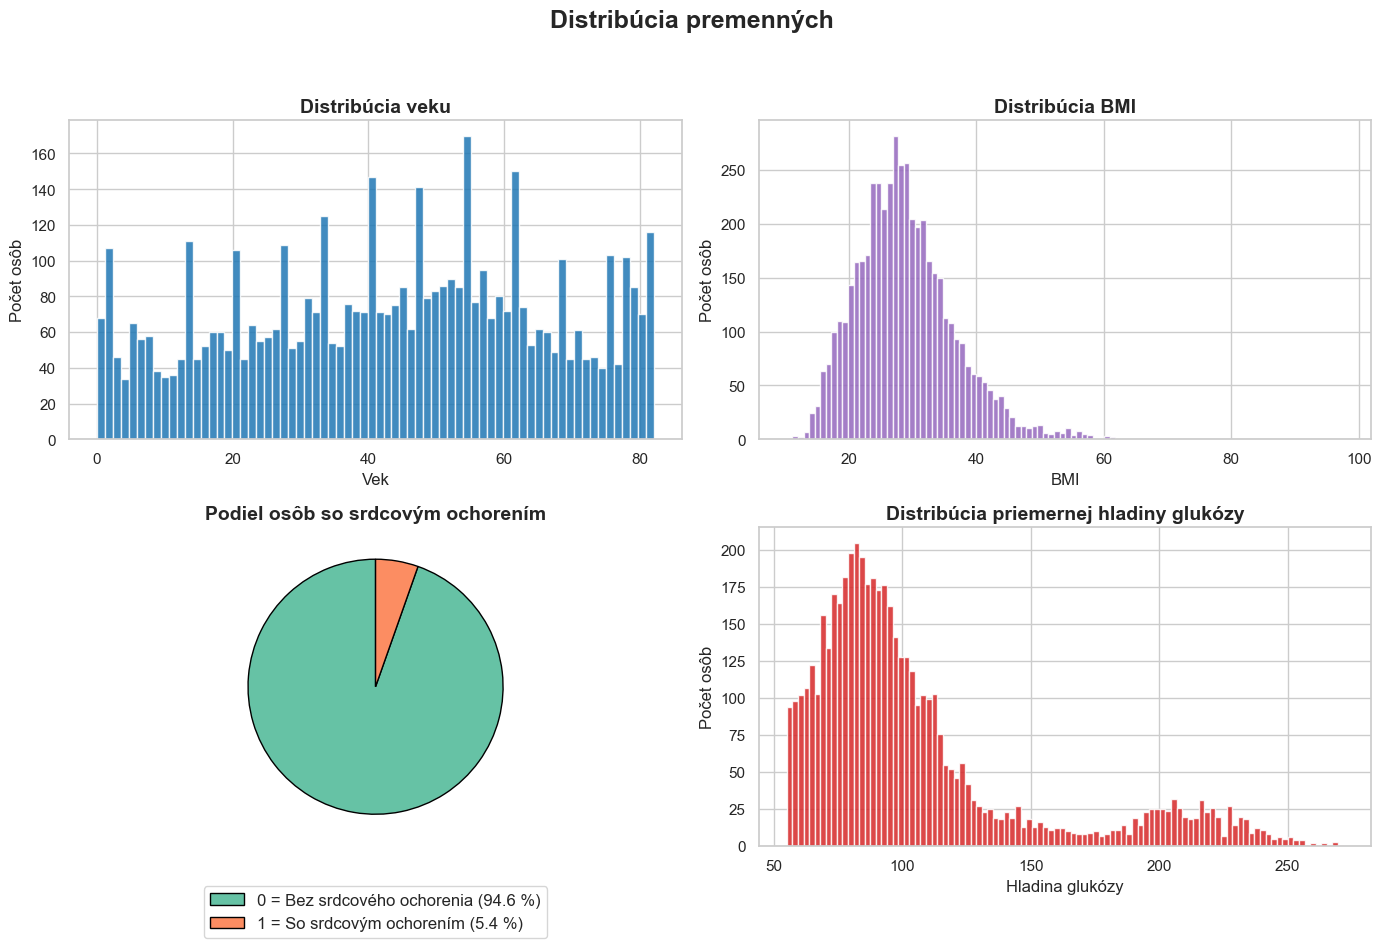

In [84]:
heart_counts = df["heart_disease"].value_counts().sort_index()
total = heart_counts.sum()
percentages = (heart_counts / total * 100).round(1)

labels = [
    f'0 = Bez srdcového ochorenia ({percentages[0]} %)',
    f'1 = So srdcovým ochorením ({percentages[1]} %)'
]

colors = ['#66c2a5', '#fc8d62']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle("Distribúcia premenných", fontsize=18, fontweight='bold')

df["age"].plot(kind="hist", bins=70, color="#1f77b4", ax=axes[0][0], alpha=0.85)
axes[0][0].set_title("Distribúcia veku", fontsize=14, fontweight='bold')
axes[0][0].set_xlabel("Vek")
axes[0][0].set_ylabel("Počet osôb")
axes[0][0].grid(True)

df["bmi"].plot(kind="hist", bins=100, color="#9467bd", ax=axes[0][1], alpha=0.85)
axes[0][1].set_title("Distribúcia BMI", fontsize=14, fontweight='bold')
axes[0][1].set_xlabel("BMI")
axes[0][1].set_ylabel("Počet osôb")
axes[0][1].grid(True)

wedges, _ = axes[1][0].pie(
    heart_counts,
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'},
    radius=1.0
)
axes[1][0].set_title("Podiel osôb so srdcovým ochorením", fontsize=14, fontweight='bold')

axes[1][0].legend(
    wedges,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    fontsize=12,
    ncol=1
)

df["avg_glucose_level"].plot(kind="hist", bins=100, color="#d62728", ax=axes[1][1], alpha=0.85)
axes[1][1].set_title("Distribúcia priemernej hladiny glukózy", fontsize=14, fontweight='bold')
axes[1][1].set_xlabel("Hladina glukózy")
axes[1][1].set_ylabel("Počet osôb")
axes[1][1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Korelačná matica**

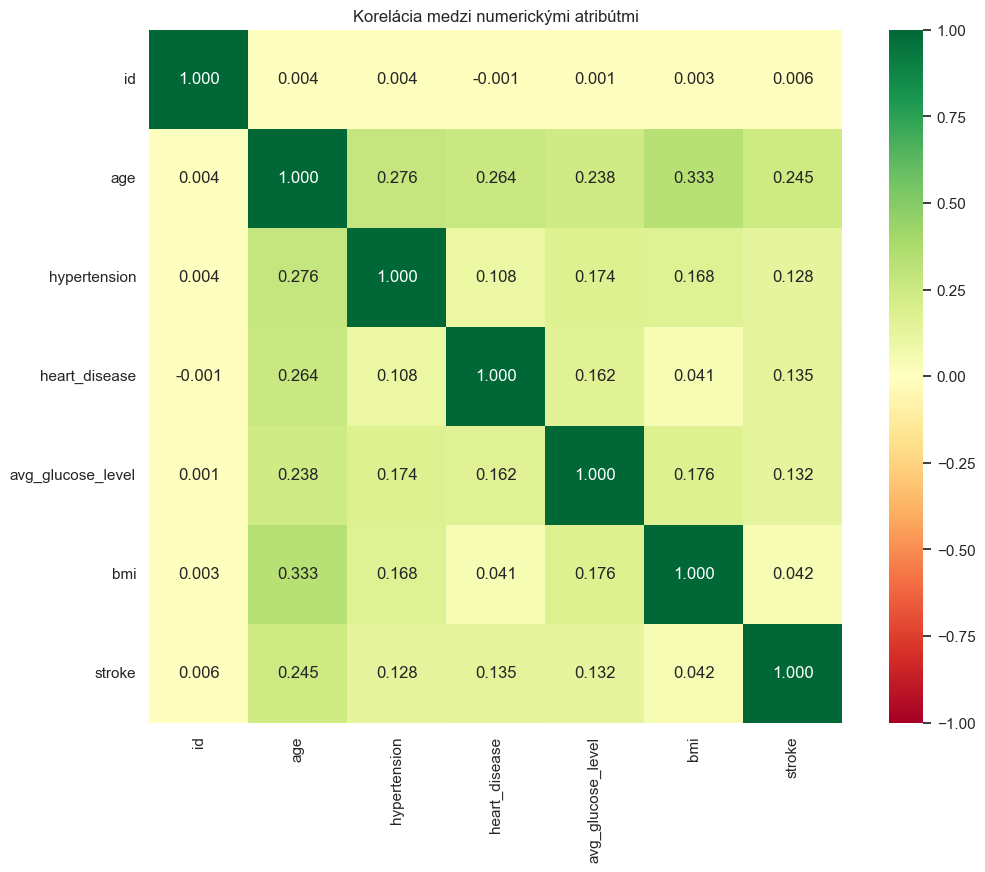

In [85]:
numerical_features = df.select_dtypes(include=np.number)

df_corr = numerical_features.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(df_corr, square=True, cmap='RdYlGn', vmin=-1, vmax=1, annot=True, fmt=".3f")
plt.title('Korelácia medzi numerickými atribútmi')
plt.show()

**BMI**

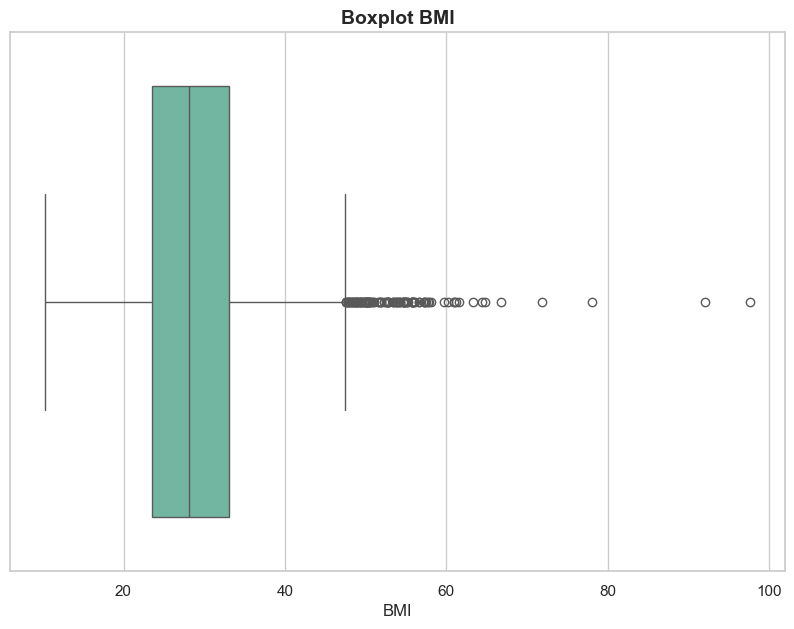

In [86]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,x=df["bmi"],color='#66c2a5');
plt.title("Boxplot BMI", fontsize=14, fontweight='bold')
plt.xlabel("BMI")
plt.show()

![Obesity Classes](obesity-classes.jpg)


**Doplneni chýbajúcich hodnôt**

In [87]:
bmi_outliers=df.loc[df['bmi']>50]
bmi_outliers['bmi'].shape

(79,)

In [88]:
print(bmi_outliers['stroke'].value_counts())

stroke
0    78
1     1
Name: count, dtype: int64


In [89]:
df["bmi"] = df["bmi"].apply(lambda x: 50 if x>50 else x)
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [90]:
print("\nPočet chýbajúcich hodnôt: ", df.isnull().sum().values.sum())


Počet chýbajúcich hodnôt:  0


**Prehľad mozgovej príhody podľa kategóriových premenných**

In [91]:
cat_df = df[['gender', 'Residence_type', 'smoking_status', 'stroke']]

summary = pd.concat(
    [pd.crosstab(cat_df[col], cat_df['stroke']) for col in cat_df.columns[:-1]],
    keys=cat_df.columns[:-1]
)

tools.display_dataframe_to_user(name="", dataframe=summary)

Loading ITables v2.5.2 from the internet... (need help?)


**Výskyt mŕtvice podľa fajčenia**

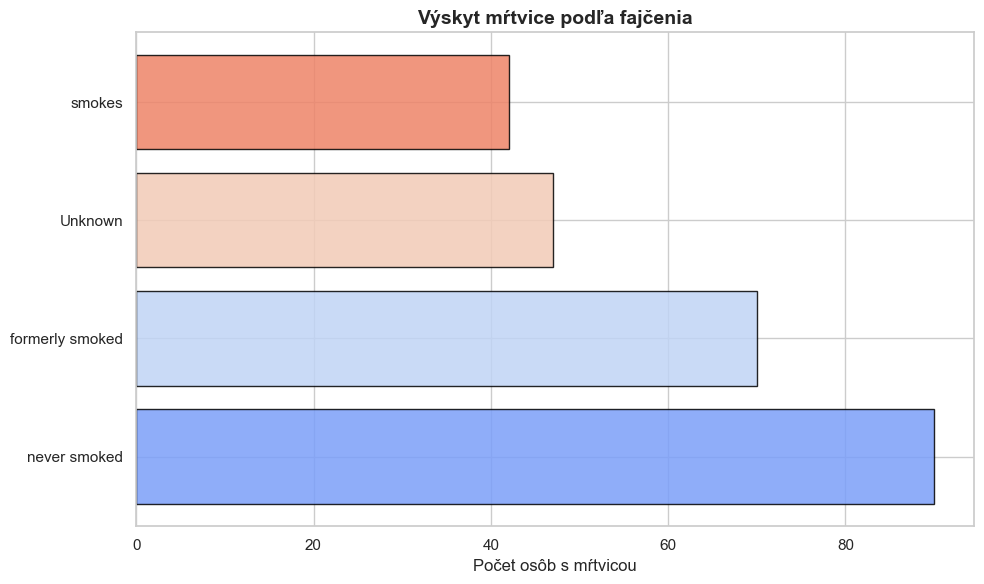

In [92]:
sns.set_theme(style="whitegrid")

stroke_df = df[df['stroke'] == 1]

counts = stroke_df['smoking_status'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.barh(
    counts.index.astype(str),
    counts.values,
    color=sns.color_palette("coolwarm", n_colors=len(counts)),
    edgecolor='black',
    alpha=0.85
)

plt.title("Výskyt mŕtvice podľa fajčenia", fontsize=14, fontweight='bold')
plt.xlabel("Počet osôb s mŕtvicou")
plt.ylabel("")



plt.tight_layout()
plt.show()


**Podiel osôb s mŕtvicou podľa manželského stavu**

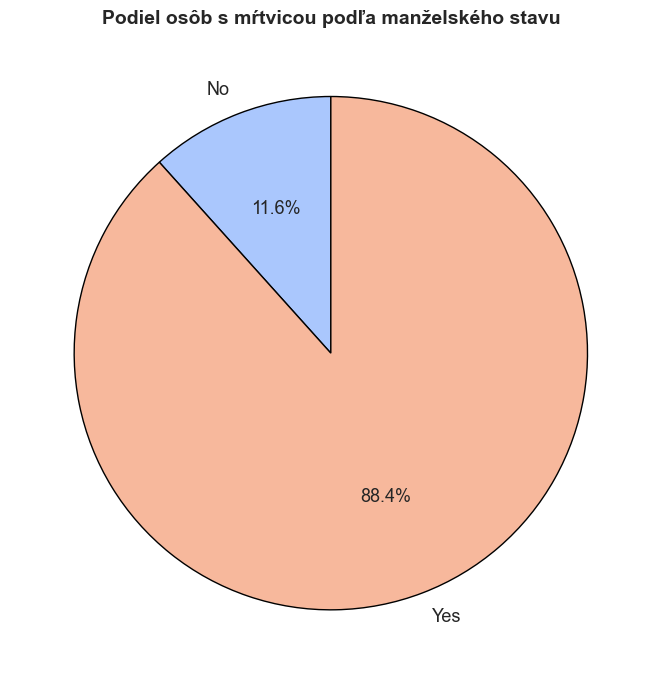

In [93]:
stroke_df = df[df['stroke'] == 1]

married_counts = stroke_df['ever_married'].value_counts().sort_index()
labels = [f'{label}' for label in married_counts.index]
colors = sns.color_palette("coolwarm", len(married_counts))

plt.figure(figsize=(7, 7))
plt.pie(
    married_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13},
    wedgeprops={'edgecolor': 'black'}
)
plt.title("Podiel osôb s mŕtvicou podľa manželského stavu", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Priemerný vek podľa manželského stavu a výskytu mŕtvice**

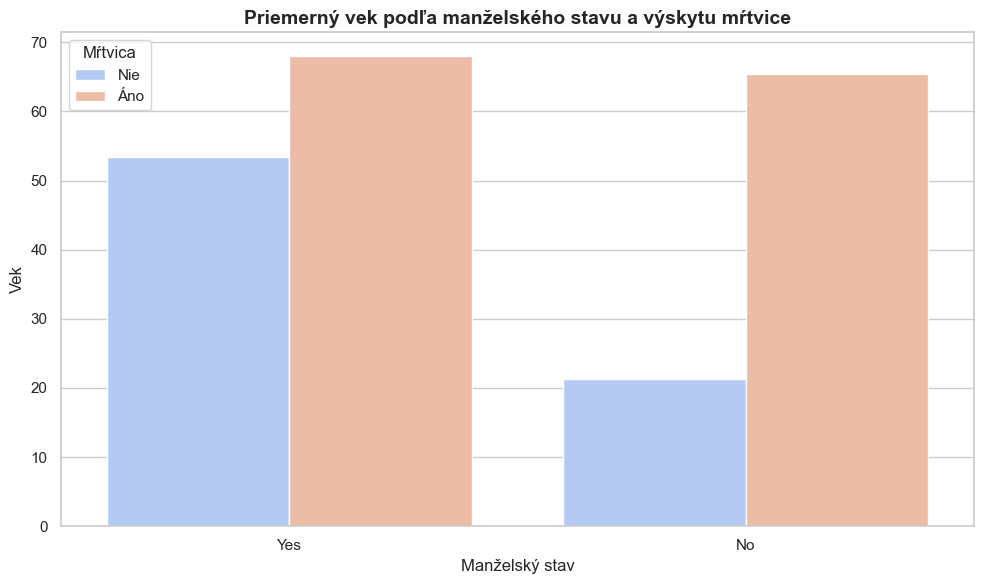

In [94]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='ever_married',
    y='age',
    hue='stroke',
    palette='coolwarm',
    errorbar=None
)

# Formátovanie
plt.title("Priemerný vek podľa manželského stavu a výskytu mŕtvice", fontsize=14, fontweight='bold')
plt.xlabel("Manželský stav")
plt.ylabel("Vek")
plt.legend(title="Mŕtvica", labels=["Nie", "Áno"])
plt.tight_layout()
plt.show()


**Výskyt mŕtvice podľa výskytu hypertenzie**

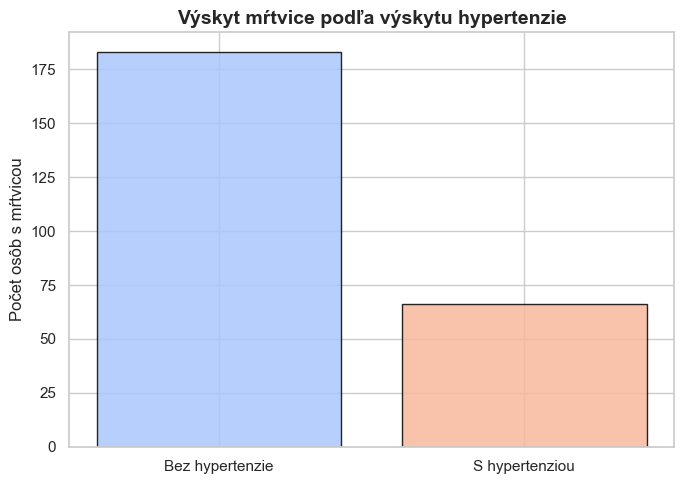

In [95]:
sns.set_theme(style="whitegrid")

stroke_df = df[df['stroke'] == 1]

hypertension_counts = stroke_df['hypertension'].value_counts().sort_index()
labels = ['Bez hypertenzie', 'S hypertenziou']
colors = sns.color_palette("coolwarm", len(hypertension_counts))

plt.figure(figsize=(7, 5))
bars = plt.bar(
    labels,
    hypertension_counts.values,
    color=colors,
    edgecolor='black',
    alpha=0.85
)

plt.title("Výskyt mŕtvice podľa výskytu hypertenzie", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Počet osôb s mŕtvicou")


plt.tight_layout()
plt.show()


**Distribúcia veku osôb s mŕtvicou**

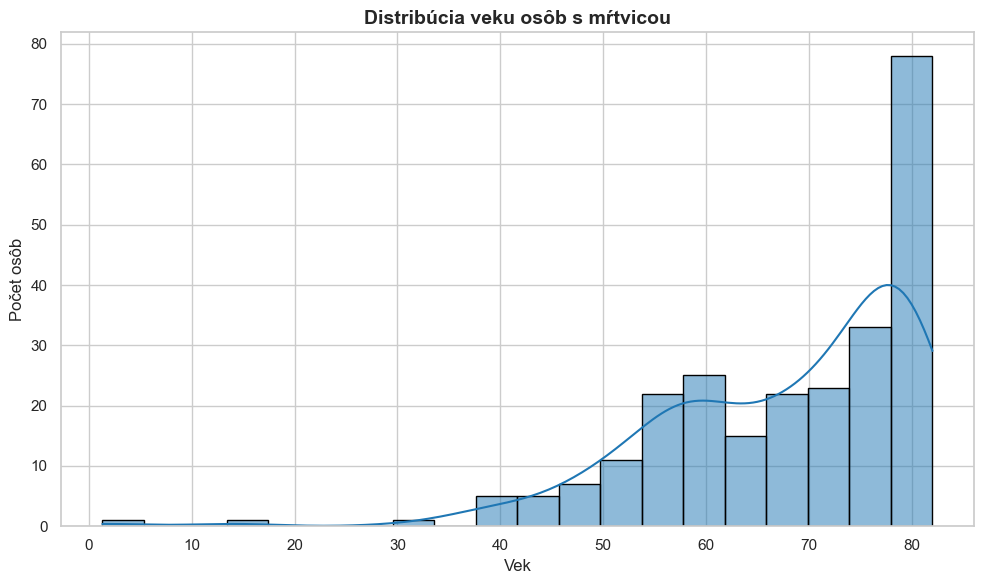

In [96]:
sns.set_theme(style="whitegrid")

stroke_df = df[df['stroke'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(stroke_df['age'], bins=20, kde=True, color='#1f77b4', edgecolor='black')

plt.title("Distribúcia veku osôb s mŕtvicou", fontsize=14, fontweight='bold')
plt.xlabel("Vek")
plt.ylabel("Počet osôb")
plt.tight_layout()
plt.show()


# **Zhodnotenie údajov**


- **Vek**  
  - Distribúcia veku ukazuje, že mozgová príhoda sa častejšie vyskytuje u starších pacientov, najmä nad 60 rokov.
  - Osoby, ktoré mali mŕtvicu, boli v priemere výrazne staršie ako tie, ktoré ju nemali – bez ohľadu na manželský stav.
  - Priemerný vek osôb s mŕtvicou bol v oboch skupinách (ženatí aj neženatí) okolo **67 rokov**, zatiaľ čo bez mŕtvice bol nižší, najmä u slobodných.

- **BMI**  
  - Väčšina pacientov sa nachádza v rozmedzí **BMI 25–35**, čo zodpovedá kategórii **nadváhy až obezity**.
  - Tieto faktory môžu súvisieť s vyšším rizikom mozgovej príhody.


# **Data preprocessing**

 Na **numerické údaje** sme použili `StandardScaler`.

- Pre **kategorické údaje** boli použité dve metódy:
  - `LabelEncoder` pre **binárne kategórie**:
    - `gender`
    - `ever_married`
    - `Residence_type`
  - `OneHotEncoder` pre **viacnásobné kategórie**:
    - `work_type`
    - `smoking_status`

In [97]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [98]:
# Kópia dát
df_encoded = df.copy()

categorical_cols = ['gender', 'ever_married', 'Residence_type', 'work_type', 'smoking_status']
label_cols = []
onehot_cols = []

for col in categorical_cols:
    if df_encoded[col].nunique() == 2:
        label_cols.append(col)
    else:
        onehot_cols.append(col)

le = LabelEncoder()
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols, drop_first=True)

df_encoded = df_encoded.astype(int)

scaler = StandardScaler()
num_cols = ['avg_glucose_level', 'bmi', 'age']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df_encoded

,id,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,1.050950,0,1,1,1,2.702438,1.045040,1,1,0,0,1,0,0,1,0,0
1,51676,0.785835,0,0,1,0,2.128117,-0.046514,1,0,0,0,0,1,0,0,1,0
2,31112,1.625367,0,1,1,0,-0.014542,0.499263,1,1,0,0,1,0,0,0,1,0
3,60182,0.255604,0,0,1,1,1.443350,0.772151,1,0,0,0,1,0,0,0,0,1
4,1665,1.581181,1,0,1,0,1.509618,-0.592291,1,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,1.625367,1,0,1,1,-0.500506,-0.046514,0,0,0,0,1,0,0,0,1,0
5106,44873,1.669553,0,0,1,1,0.427244,1.590816,0,0,0,0,0,1,0,0,1,0
5107,19723,-0.362999,0,0,1,0,-0.522595,0.226374,0,0,0,0,0,1,0,0,1,0
5108,37544,0.343976,0,0,1,0,1.332903,-0.455846,0,1,0,0,1,0,0,1,0,0


# **Clusteringová Analýza**

## Príprava dát pre clustering

Pre clustering budeme používať dáta bez cieľovej premennej `stroke`.

In [100]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## Výber atribútov pre clustering

Budeme testovať 2 rôzne prístupy k výberu atribútov:
1. **Kompletný dataset** - všetky dostupné atribúty
2. **SelectKBest** - automatický výber najlepších atribútov

In [101]:
X_clustering = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

print("Atribúty dostupné pre clustering:")
print(X_clustering.columns.tolist())
print(f"\nCelkový počet atribútov: {X_clustering.shape[1]}")
print(f"Celkový počet vzoriek v datasete: {X_clustering.shape[0]}")

Atribúty dostupné pre clustering:
['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'gender_Male', 'gender_Other', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

Celkový počet atribútov: 16
Celkový počet vzoriek v datasete: 5110


### Prístup 1: Kompletný dataset

Použitie všetkých dostupných atribútov.

In [102]:
X_complete = X_clustering.copy()
print(f"Prístup 1 - Kompletný dataset:")
print(f"Počet atribútov: {X_complete.shape[1]}")
print(f"Použité atribúty: {X_complete.columns.tolist()}")

Prístup 1 - Kompletný dataset:
Počet atribútov: 16
Použité atribúty: ['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'gender_Male', 'gender_Other', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


### Prístup 2: SelectKBest s chi² testom

Použijeme SelectKBest na automatický výber najlepších K atribútov na základe štatistického testu.

In [103]:
k_best = 8  

from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(X_clustering),
    columns=X_clustering.columns
)

selector_chi2 = SelectKBest(chi2, k=k_best)
X_chi2 = selector_chi2.fit_transform(X_scaled, y)

chi2_features = X_clustering.columns[selector_chi2.get_support()].tolist()
X_selectkbest = X_clustering[chi2_features].copy()

print(f"Prístup 2 - SelectKBest (chi²):")
print(f"Počet automaticky vybraných atribútov: {X_selectkbest.shape[1]}")
print(f"Vybrané atribúty: {chi2_features}")
print(f"\nChi² skóre jednotlivých atribútov:")
for feature, score in sorted(zip(X_clustering.columns, selector_chi2.scores_), key=lambda x: x[1], reverse=True):
    print(f" {feature}: {score:.4f}")

Prístup 2 - SelectKBest (chi²):
Počet automaticky vybraných atribútov: 8
Vybrané atribúty: ['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked']

Chi² skóre jednotlivých atribútov:
 heart_disease: 87.9874
 hypertension: 75.4495
 age: 44.3801
 work_type_children: 31.1116
 ever_married: 20.6228
 smoking_status_formerly smoked: 17.6074
 avg_glucose_level: 16.6545
 work_type_Self-employed: 16.5843
 work_type_Never_worked: 1.1269
 bmi: 0.6386
 Residence_type: 0.6007
 smoking_status_smokes: 0.3453
 work_type_Private: 0.3088
 gender_Male: 0.2490
 smoking_status_never smoked: 0.0549
 gender_Other: 0.0512


## Clusteringové metódy

Použijeme tri rôzne clusteringové metódy:
1. **K-Means** 
2. **DBSCAN**
3. **Aglomeratívny clustering** 

Každú metódu aplikujeme na dva prístupy výberu atribútov.

### 1. K-Means


1. Kompletný dataset:


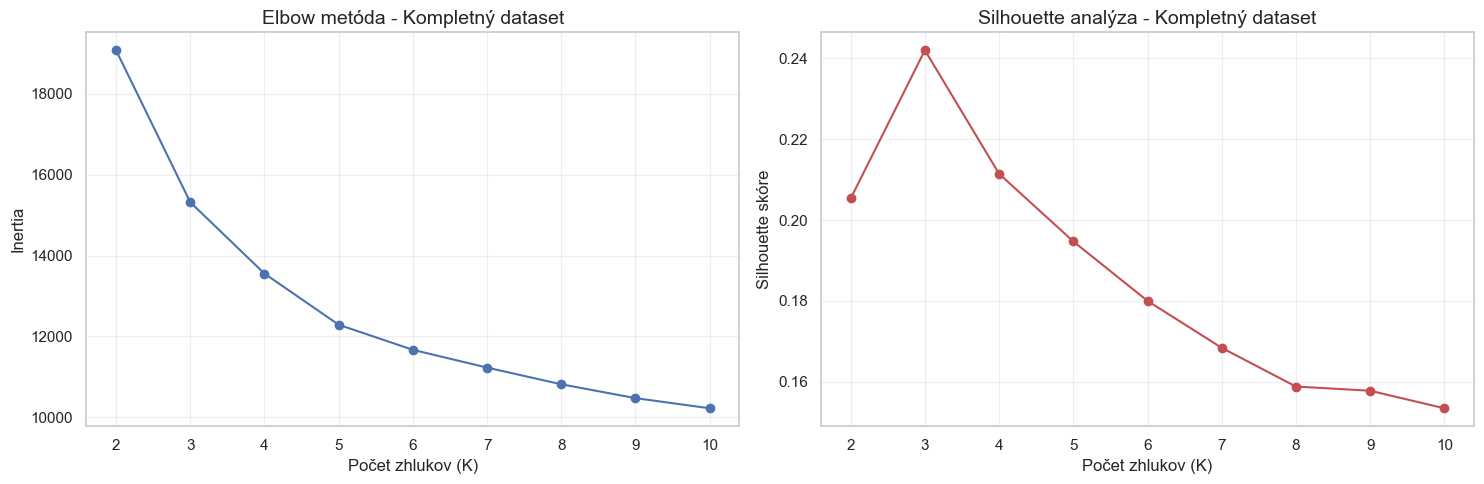


Odporúčaný počet zhlukov (max Silhouette): 3
Silhouette skóre: 0.2420

2. SelectKBest:


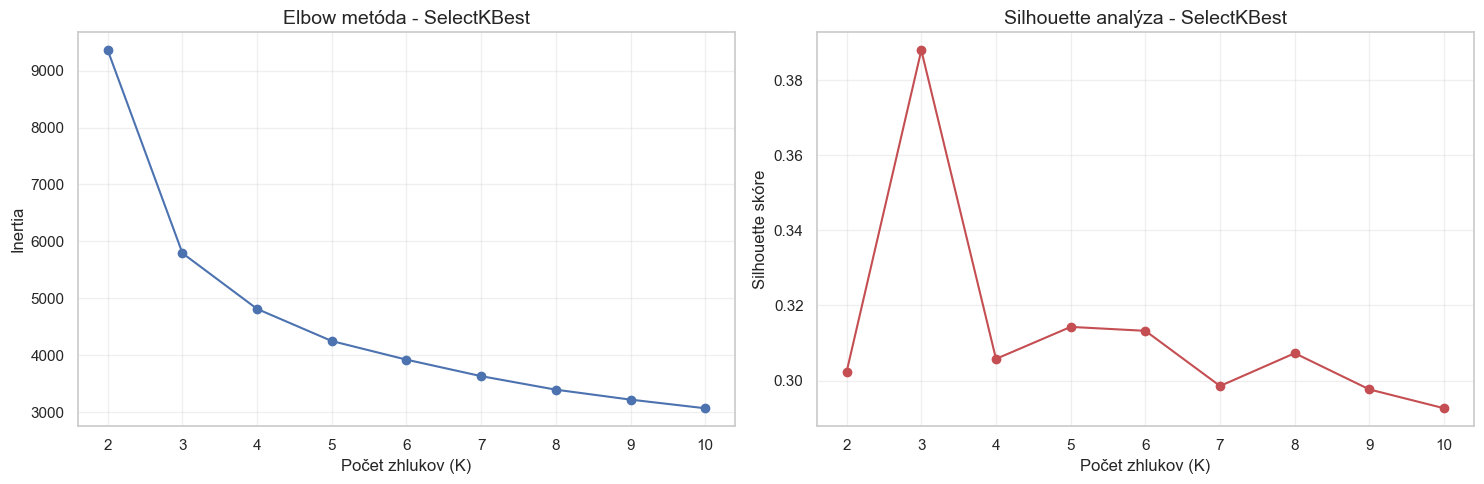


Odporúčaný počet zhlukov (max Silhouette): 3
Silhouette skóre: 0.3880


In [104]:
def find_optimal_clusters(X, name, max_k=10):
    inertias = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Elbow graf
    ax1.plot(K_range, inertias, 'bo-')
    ax1.set_xlabel('Počet zhlukov (K)', fontsize=12)
    ax1.set_ylabel('Inertia', fontsize=12)
    ax1.set_title(f'Elbow metóda - {name}', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Silhouette skóre
    ax2.plot(K_range, silhouette_scores, 'ro-')
    ax2.set_xlabel('Počet zhlukov (K)', fontsize=12)
    ax2.set_ylabel('Silhouette skóre', fontsize=12)
    ax2.set_title(f'Silhouette analýza - {name}', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
    print(f"\nOdporúčaný počet zhlukov (max Silhouette): {best_k}")
    print(f"Silhouette skóre: {max(silhouette_scores):.4f}")
    
    return best_k


print("\n1. Kompletný dataset:")
k_complete = find_optimal_clusters(X_complete, "Kompletný dataset")

print("\n2. SelectKBest:")
k_selectkbest = find_optimal_clusters(X_selectkbest, "SelectKBest")

In [125]:
def perform_kmeans(X, n_clusters, name):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    silhouette = silhouette_score(X, labels)
   

    print(f"\n{name}:")
    print(f"  Počet zhlukov: {n_clusters}")
    print(f"  Silhouette skóre: {silhouette:.4f}")

    return labels, kmeans


labels_kmeans_complete, model_kmeans_complete = perform_kmeans(
    X_complete, k_complete, "Prístup 1: Kompletný dataset"
)

labels_kmeans_selectkbest, model_kmeans_selectkbest = perform_kmeans(
    X_selectkbest, k_selectkbest, "Prístup 2: SelectKBest"
)


Prístup 1: Kompletný dataset:
  Počet zhlukov: 3
  Silhouette skóre: 0.2420

Prístup 2: SelectKBest:
  Počet zhlukov: 3
  Silhouette skóre: 0.3880

Prístup 2: SelectKBest:
  Počet zhlukov: 3
  Silhouette skóre: 0.3880


### 2. DBSCAN


1. Kompletný dataset:


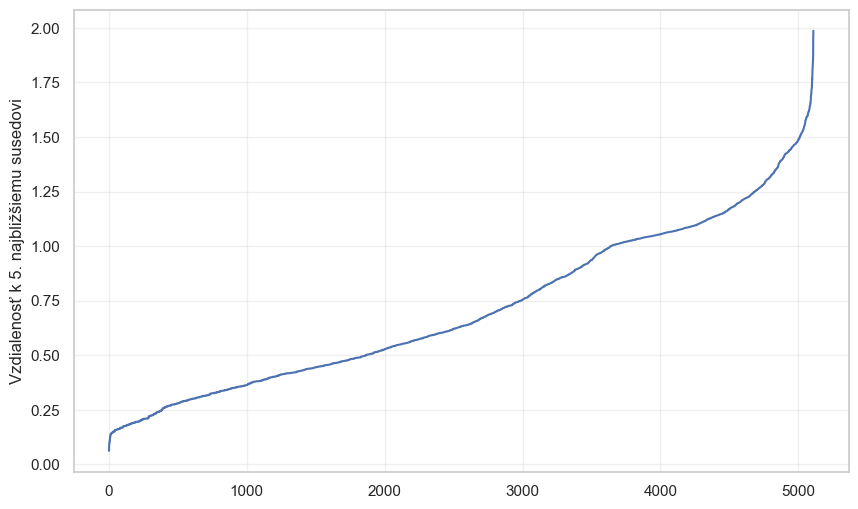

Odhadovaný eps (90. percentil): 1.2122

2. SelectKBest:


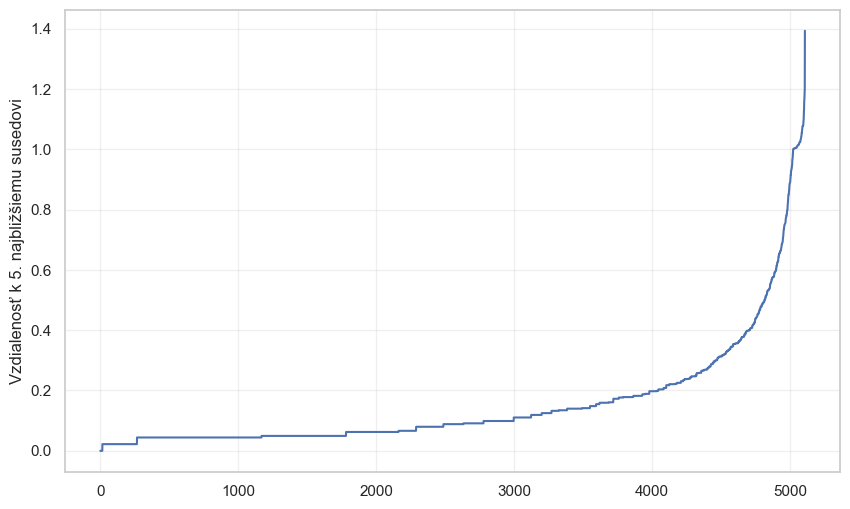

Odhadovaný eps (90. percentil): 0.3542


In [106]:
def find_dbscan_params(X, name):
    from sklearn.neighbors import NearestNeighbors
    
    neighbors = NearestNeighbors(n_neighbors=5)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    
    distances = np.sort(distances[:, -1], axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.ylabel('Vzdialenosť k 5. najbližšiemu susedovi', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    eps_estimate = np.percentile(distances, 90)
    print(f"Odhadovaný eps (90. percentil): {eps_estimate:.4f}")
    
    return eps_estimate


print("\n1. Kompletný dataset:")
eps_complete = find_dbscan_params(X_complete, "Kompletný dataset")

print("\n2. SelectKBest:")
eps_selectkbest = find_dbscan_params(X_selectkbest, "SelectKBest")

In [107]:
def perform_dbscan(X, eps, min_samples, name):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"\n{name}:")
    print(f"  eps: {eps:.4f}")
    print(f"  min_samples: {min_samples}")
    print(f"  Počet identifikovaných zhlukov: {n_clusters}")
    print(f"  Počet šumových bodov: {n_noise}")
    
    if n_clusters > 1:
        mask = labels != -1
        if mask.sum() > 0:
            silhouette = silhouette_score(X[mask], labels[mask])
            
            print(f"Silhouette skóre: {silhouette:.4f}")
           
    return labels, dbscan


min_samples = 5 

labels_dbscan_complete, model_dbscan_complete = perform_dbscan(
    X_complete, eps_complete, min_samples, "Prístup 1: Kompletný dataset"
)

labels_dbscan_selectkbest, model_dbscan_selectkbest = perform_dbscan(
    X_selectkbest, eps_selectkbest, min_samples, "Prístup 2: SelectKBest"
)


Prístup 1: Kompletný dataset:
  eps: 1.2122
  min_samples: 5
  Počet identifikovaných zhlukov: 1
  Počet šumových bodov: 201

Prístup 2: SelectKBest:
  eps: 0.3542
  min_samples: 5
  Počet identifikovaných zhlukov: 31
  Počet šumových bodov: 349

Prístup 2: SelectKBest:
  eps: 0.3542
  min_samples: 5
  Počet identifikovaných zhlukov: 31
  Počet šumových bodov: 349
Silhouette skóre: 0.1925
Silhouette skóre: 0.1925


### 3. Aglomeratívny

1. Kompletný dataset:


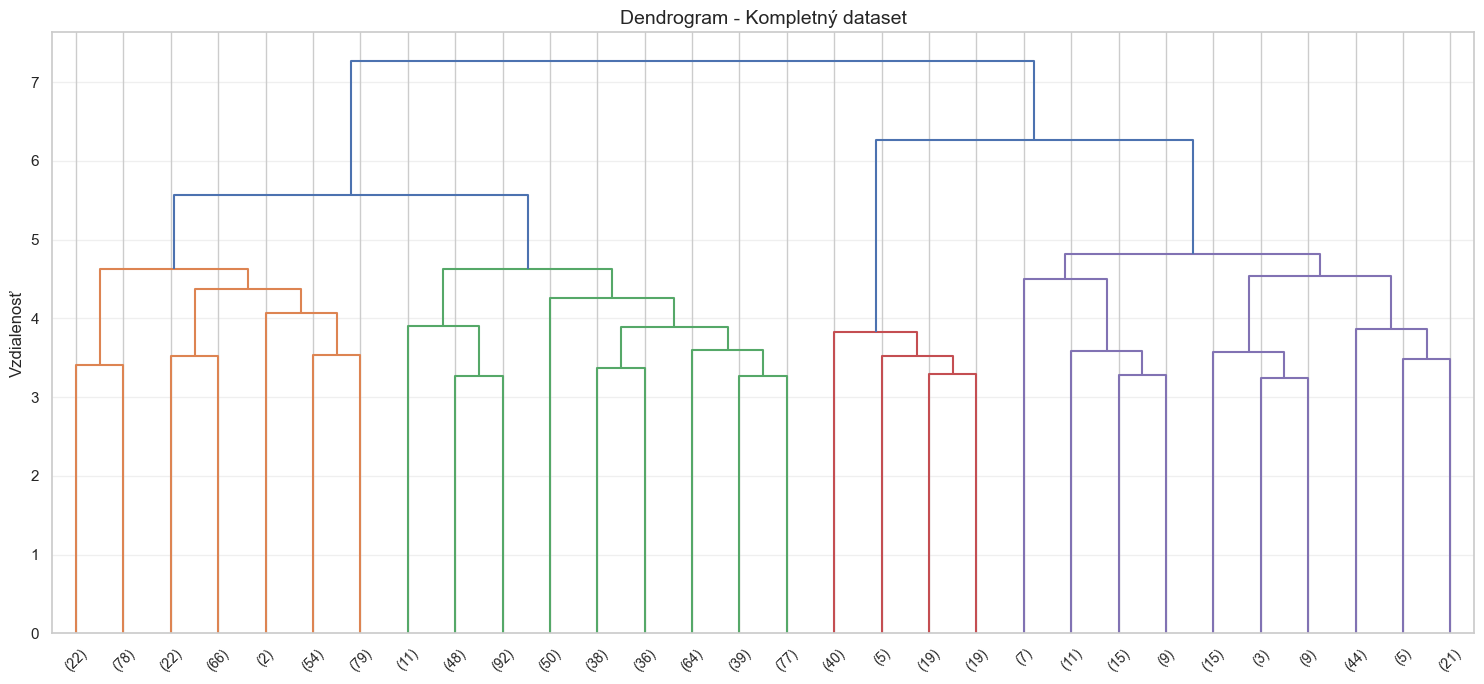


2. SelectKBest:


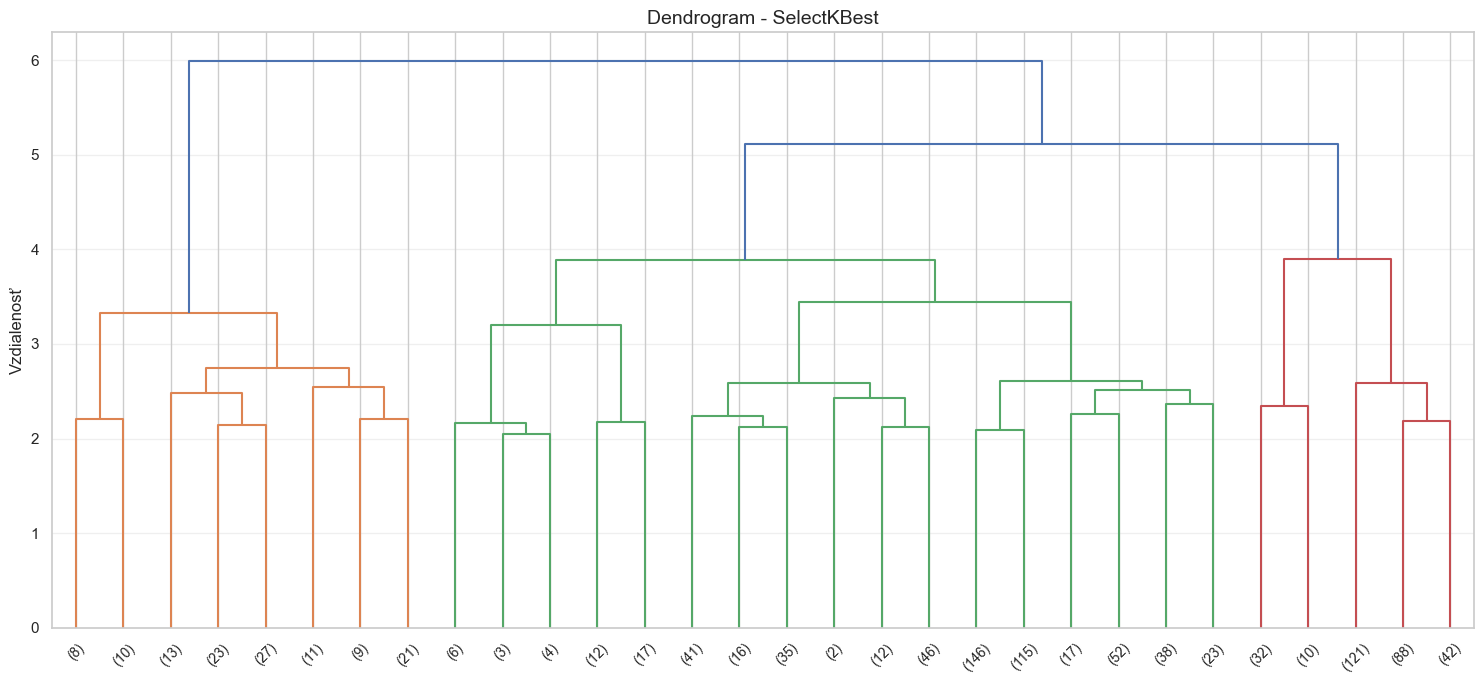

In [117]:
def plot_dendrogram(X, name, max_display=30):
    sample_size = min(1000, len(X))
    sample_indices = np.random.choice(len(X), sample_size, replace=False)
    X_sample = X.iloc[sample_indices] if hasattr(X, 'iloc') else X[sample_indices]
    
    linkage_matrix = linkage(X_sample, method='complete')
    
    plt.figure(figsize=(15, 7))
    dendrogram(
        linkage_matrix,
        truncate_mode='lastp',
        p=max_display,
        show_leaf_counts=True,
        leaf_font_size=10
    )
    plt.ylabel('Vzdialenosť', fontsize=12)
    plt.title(f'Dendrogram - {name}', fontsize=14)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    return linkage_matrix



print("1. Kompletný dataset:")
linkage_complete = plot_dendrogram(X_complete, "Kompletný dataset")

print("\n2. SelectKBest:")
linkage_selectkbest = plot_dendrogram(X_selectkbest, "SelectKBest")


1. Kompletný dataset:
  K=2: Silhouette = 0.2604
  K=2: Silhouette = 0.2604
  K=3: Silhouette = 0.1661
  K=3: Silhouette = 0.1661
  K=4: Silhouette = 0.1755
  K=4: Silhouette = 0.1755
  K=5: Silhouette = 0.1577
  K=5: Silhouette = 0.1577
  K=6: Silhouette = 0.1016
  K=6: Silhouette = 0.1016
  K=7: Silhouette = 0.0971
  K=7: Silhouette = 0.0971
  K=8: Silhouette = 0.0947
  K=8: Silhouette = 0.0947
  K=9: Silhouette = 0.0964
  K=9: Silhouette = 0.0964
  K=10: Silhouette = 0.0930
  K=10: Silhouette = 0.0930


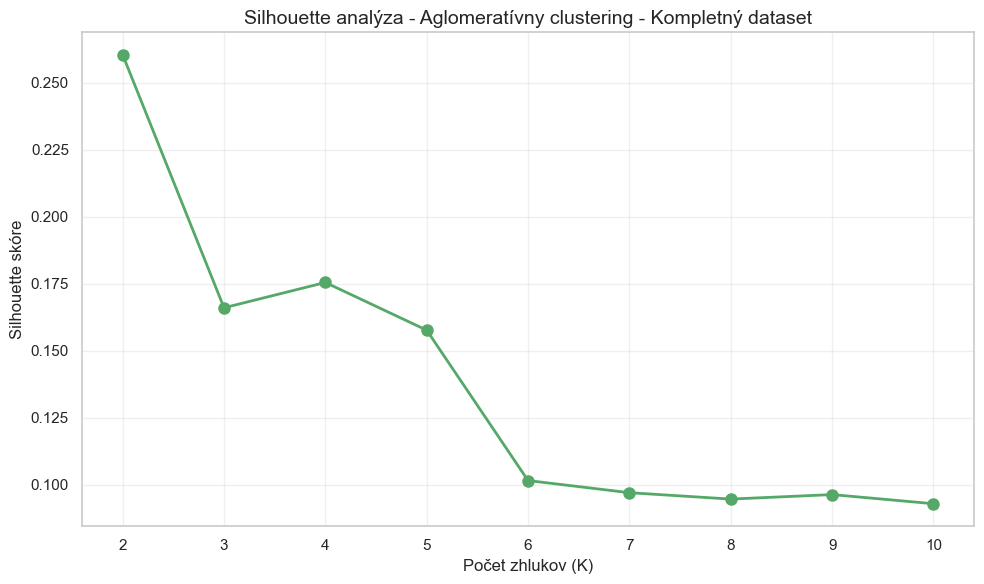


Odporúčaný počet zhlukov: 2
Najlepšie Silhouette skóre: 0.2604

2. SelectKBest:
  K=2: Silhouette = 0.4392
  K=2: Silhouette = 0.4392
  K=3: Silhouette = 0.3731
  K=3: Silhouette = 0.3731
  K=4: Silhouette = 0.3522
  K=4: Silhouette = 0.3522
  K=5: Silhouette = 0.2668
  K=5: Silhouette = 0.2668
  K=6: Silhouette = 0.2553
  K=6: Silhouette = 0.2553
  K=7: Silhouette = 0.2369
  K=7: Silhouette = 0.2369
  K=8: Silhouette = 0.1896
  K=8: Silhouette = 0.1896
  K=9: Silhouette = 0.1604
  K=9: Silhouette = 0.1604
  K=10: Silhouette = 0.1622
  K=10: Silhouette = 0.1622


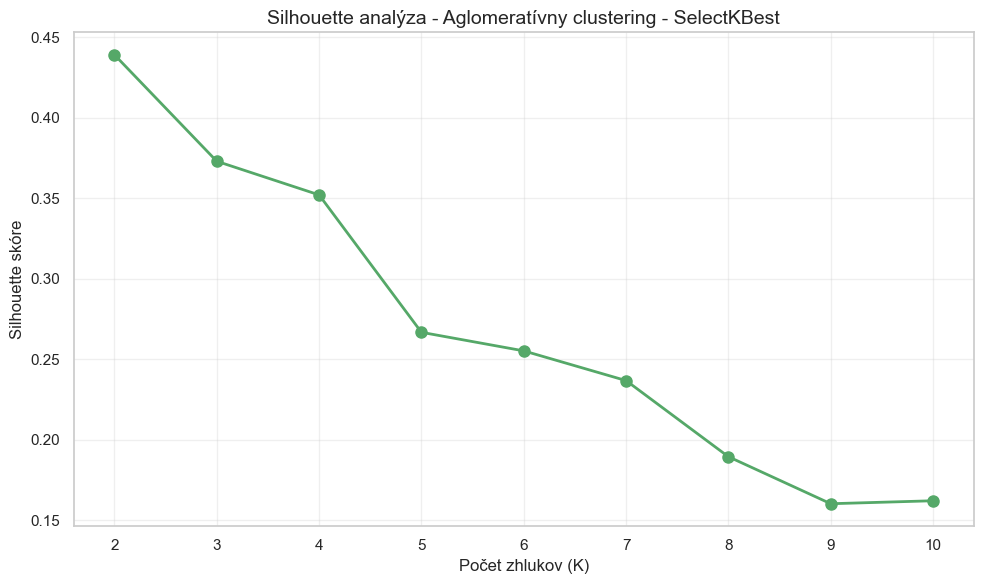


Odporúčaný počet zhlukov: 2
Najlepšie Silhouette skóre: 0.4392



In [119]:
def find_optimal_agglomerative(X, name, max_k=10):
   
    silhouette_scores = []
    K_range = range(2, max_k + 1)
    
    for k in K_range:
        agglo = AgglomerativeClustering(n_clusters=k, linkage='complete')
        labels = agglo.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        print(f"  K={k}: Silhouette = {score:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    plt.xlabel('Počet zhlukov (K)', fontsize=12)
    plt.ylabel('Silhouette skóre', fontsize=12)
    plt.title(f'Silhouette analýza - Aglomeratívny clustering - {name}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
    print(f"\nOdporúčaný počet zhlukov: {best_k}")
    print(f"Najlepšie Silhouette skóre: {max(silhouette_scores):.4f}\n")
    
    return best_k



print("\n1. Kompletný dataset:")
k_agglo_complete = find_optimal_agglomerative(X_complete, "Kompletný dataset")

print("2. SelectKBest:")
k_agglo_selectkbest = find_optimal_agglomerative(X_selectkbest, "SelectKBest")

In [120]:
def perform_agglomerative(X, n_clusters, name):
    agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = agglo.fit_predict(X)
    
    silhouette = silhouette_score(X, labels)
   
    print(f"\n{name}:")
    print(f"Počet zhlukov: {n_clusters}")
    print(f"Silhouette skóre: {silhouette:.4f}")
    
    return labels, agglo

labels_agglo_complete, model_agglo_complete = perform_agglomerative(
    X_complete, k_agglo_complete, "Prístup 1: Kompletný dataset"
)
labels_agglo_selectkbest, model_agglo_selectkbest = perform_agglomerative(
    X_selectkbest, k_agglo_selectkbest, "Prístup 2: SelectKBest"
)


Prístup 1: Kompletný dataset:
Počet zhlukov: 2
Silhouette skóre: 0.2060

Prístup 2: SelectKBest:
Počet zhlukov: 2
Silhouette skóre: 0.3954

Prístup 2: SelectKBest:
Počet zhlukov: 2
Silhouette skóre: 0.3954


## Vizualizácia výsledkov clusteringu

In [128]:
from sklearn.decomposition import PCA

def visualize_clusters(X, labels, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='RdYlGn', alpha=0.6, edgecolors='k', linewidth=0.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


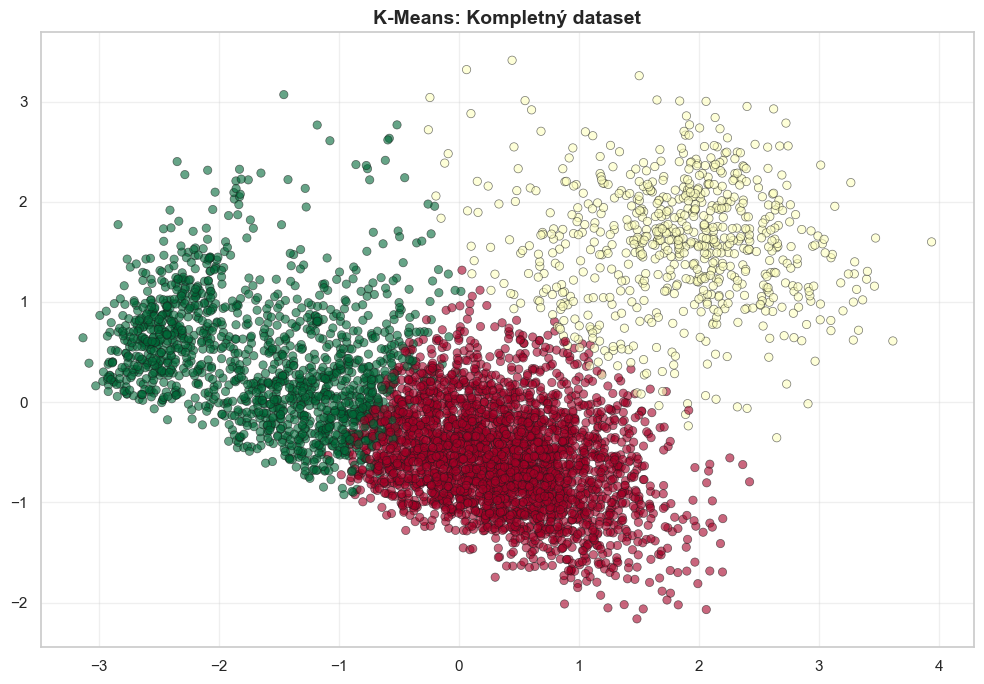

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
cluster,,,,,,,,,,,,,,,,,
0,0.410425,0.106218,0.055462,0.871261,0.505546,-0.378031,0.285676,0.051765,0.387563,0.000000,0.000672,0.633613,0.205042,0.000000,0.207059,0.409412,0.185546
1,0.779387,0.256080,0.155937,0.904149,0.523605,2.175898,0.560946,0.131617,0.477825,0.000000,0.000000,0.602289,0.237482,0.001431,0.264664,0.410587,0.168813
2,-1.229670,0.002089,0.001393,0.089833,0.505571,-0.275983,-0.864894,0.002089,0.437326,0.000696,0.013928,0.431058,0.029944,0.477716,0.058496,0.269499,0.082869


In [ ]:
visualize_clusters(X_complete, labels_kmeans_complete, 
                  "K-Means: Kompletný dataset")

df_encoded["cluster"] = labels_kmeans_complete
cluster_summary = df_encoded.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

- **Cluster 0 – Mladší, relatívne zdraví:**
  - Nižší vek, minimum prípadov hypertenzie a mŕtvice
  - Väčšina pracujúcich v súkromnom sektore
  - Prevažujúci rodinný stav: ženatý/vydatá

- **Cluster 1 – Starší s vyšším rizikom:**
  - Vyšší vek, častejšie výskyt mŕtvice, hypertenzie a srdcových ochorení
  - Výrazne vyššie BMI a hladina glukózy
  - Riziková skupina pre zdravotné intervencie

- **Cluster 2 – Mladí a bez rizika:**
  - Najmladšia skupina, minimálne zdravotné problémy
  - Často ešte bez pracovného pomeru (deti, študenti)
  - Veľmi nízky výskyt mozgovej príhody


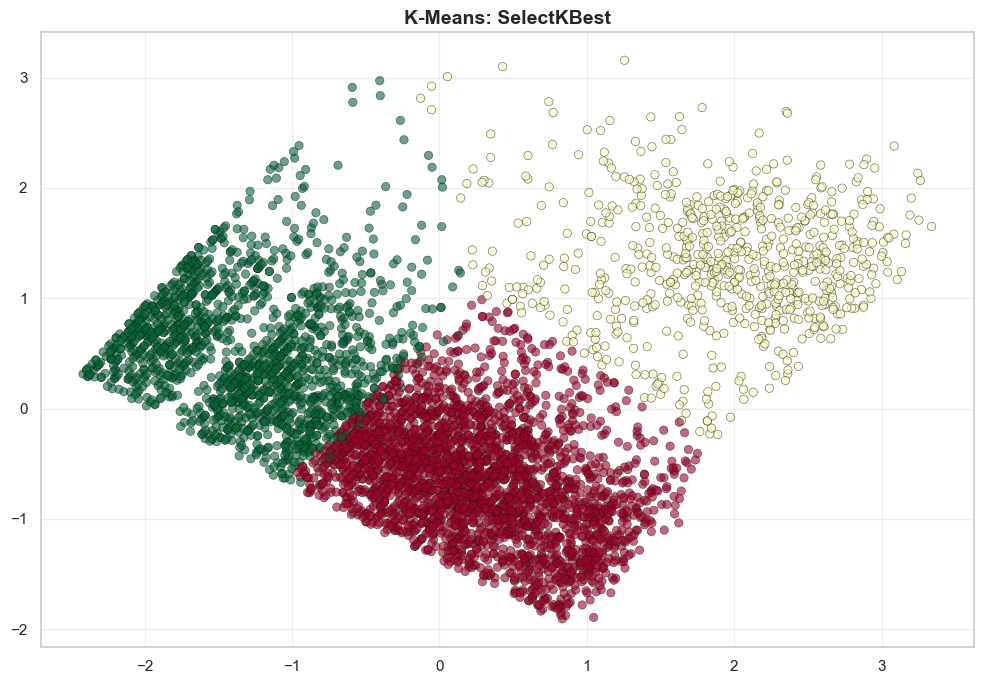

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
cluster,,,,,,,,,,,,,,,,,
0,0.496076,0.110392,0.059331,0.925926,0.510608,-0.373776,0.198507,0.056095,0.390507,0.000000,0.000000,0.614527,0.218626,0.000000,0.212873,0.400575,0.184466
1,0.766385,0.252137,0.155271,0.900285,0.521368,2.180823,0.514812,0.129630,0.477208,0.000000,0.000000,0.601140,0.233618,0.005698,0.262108,0.413105,0.170940
2,-1.178605,0.008605,0.001229,0.089736,0.497849,-0.302069,-0.561429,0.001229,0.426552,0.000615,0.013522,0.488015,0.028888,0.419791,0.066994,0.299939,0.095882


In [130]:
visualize_clusters(X_selectkbest, labels_kmeans_selectkbest, 
                  "K-Means: SelectKBest")
df_encoded["cluster"] = labels_kmeans_selectkbest
cluster_summary = df_encoded.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

- **Cluster 0 – Mladší a zdravší:**
  - Priemerne mladší vek (age ~0.5)
  - Nízky výskyt hypertenzie a srdcových ochorení
  - Väčšina bola niekedy ženatá/vydatá
  - Prevažuje práca v súkromnom sektore
  - Väčšina nefajčí alebo prestala fajčiť
  - Nízky výskyt mŕtvice

- **Cluster 1 – Starší s vyšším zdravotným rizikom:**
  - Najvyšší vekový priemer (age ~0.77)
  - Vyšší výskyt hypertenzie, srdcových chorôb aj mŕtvice
  - Výrazne zvýšená hladina glukózy a vyššie BMI
  - Viac bývalých fajčiarov
  - Podobné zastúpenie práce ako cluster 0

- **Cluster 2 – Najmladší, nízke riziko:**
  - Najnižší vek (age ~-1.18)
  - Minimálny výskyt hypertenzie, srdcových chorôb a mŕtvice
  - Nižšie BMI, nižšia hladina glukózy
  - Mnohí sú ešte deti alebo bez práce
  - Nízka úroveň fajčenia

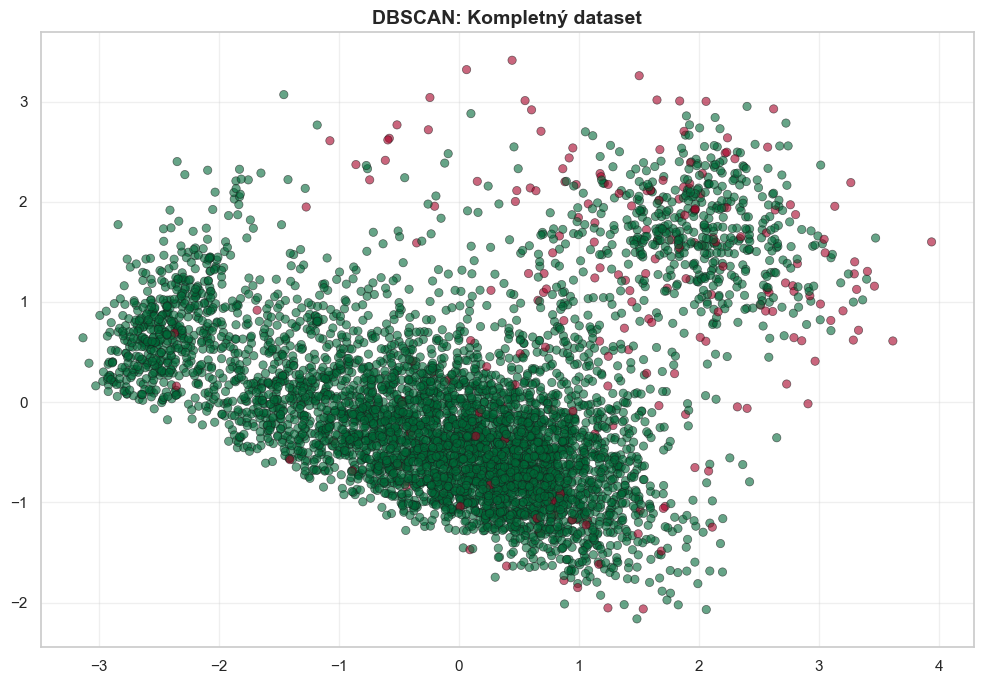

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
cluster,,,,,,,,,,,,,,,,,
-1,0.488844,0.39801,0.293532,0.577114,0.537313,1.450493,0.699517,0.109453,0.447761,0.000000,0.034826,0.298507,0.358209,0.034826,0.283582,0.283582,0.218905
0,-0.020016,0.08515,0.044205,0.659401,0.506824,-0.059391,-0.028642,0.046242,0.412508,0.000204,0.003056,0.583622,0.152169,0.138521,0.168670,0.373803,0.151762


In [131]:
visualize_clusters(X_complete, labels_dbscan_complete, 
                  "DBSCAN: Kompletný dataset")
df_encoded["cluster"] = labels_dbscan_complete
cluster_summary = df_encoded.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

- **Cluster -1 – Zdravotne rizikovejší / Outliers:**
  - Vyššie hodnoty veku, BMI aj glukózy
  - Výrazne vyšší výskyt hypertenzie (0.40) a srdcových ochorení (0.29)
  - Viac osôb so skúsenosťou s fajčením (bývalí alebo aktuálni fajčiari)
  - Vyššie zastúpenie samostatne zárobkovo činných
  - Mierne vyšší výskyt mŕtvice

- **Cluster 0 – Nižšie riziko:**
  - Nižšie hodnoty veku, BMI aj glukózy
  - Výrazne nižší výskyt hypertenzie (0.08) a srdcových ochorení (0.04)
  - Viac ľudí pracujúcich v súkromnom sektore
  - Prevažujú nefajčiari
  - Nižší výskyt mŕtvice

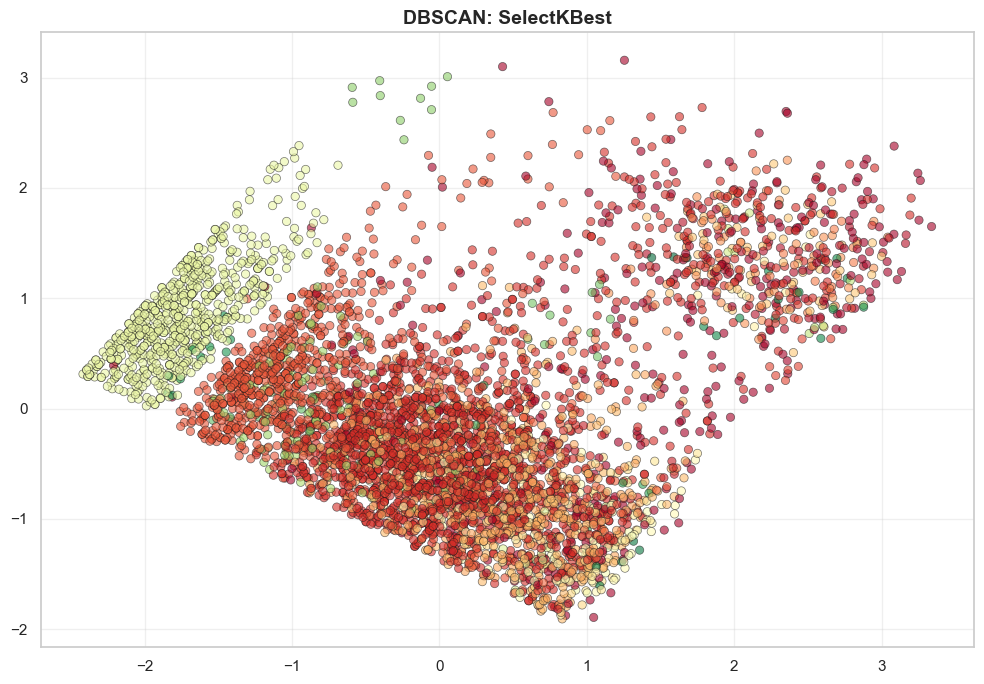

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
cluster,,,,,,,,,,,,,,,,,
-1,0.766970,0.481375,0.452722,0.638968,0.538682,1.046313,0.322941,0.114613,0.518625,0.002865,0.000000,0.467049,0.412607,0.008596,0.484241,0.277937,0.146132
0,0.975466,0.000000,0.000000,1.000000,0.458333,2.456235,0.541902,0.083333,0.354167,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.583333,0.291667
1,1.038761,0.000000,1.000000,1.000000,0.413793,-0.348928,0.165210,0.155172,0.637931,0.000000,0.000000,0.741379,0.000000,0.000000,0.000000,0.517241,0.293103
2,0.262893,0.000000,0.000000,1.000000,0.516496,-0.026365,0.235766,0.039818,0.374858,0.000000,0.000000,0.795222,0.000000,0.000000,0.000000,0.502844,0.229807
3,1.490210,1.000000,0.000000,1.000000,0.529412,1.950103,0.242427,0.294118,0.235294,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.823529,0.000000
4,-0.707237,0.000000,0.000000,0.000000,0.491803,-0.245713,-0.115510,0.012610,0.368222,0.000000,0.027743,0.861286,0.000000,0.000000,0.000000,0.503153,0.189155
5,0.606473,1.000000,0.000000,1.000000,0.429630,-0.400695,0.440642,0.059259,0.392593,0.000000,0.000000,0.785185,0.000000,0.000000,0.000000,0.622222,0.281481
6,1.386243,0.000000,1.000000,1.000000,0.588235,2.468551,0.017695,0.411765,0.529412,0.000000,0.000000,0.941176,0.000000,0.000000,0.000000,0.647059,0.117647
7,0.871261,1.000000,0.000000,1.000000,0.566667,2.227887,0.615240,0.150000,0.433333,0.000000,0.000000,0.833333,0.000000,0.000000,0.000000,0.616667,0.283333


In [132]:
visualize_clusters(X_selectkbest, labels_dbscan_selectkbest, 
                  "DBSCAN: SelectKBest")
df_encoded["cluster"] = labels_dbscan_selectkbest
cluster_summary = df_encoded.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

Pri použití metódy **DBSCAN** bolo identifikovaných **veľké množstvo klastrov (30+)** vrátane **šumu** (`cluster -1`). Takéto rozdelenie môže byť výsledkom niekoľkých faktorov:


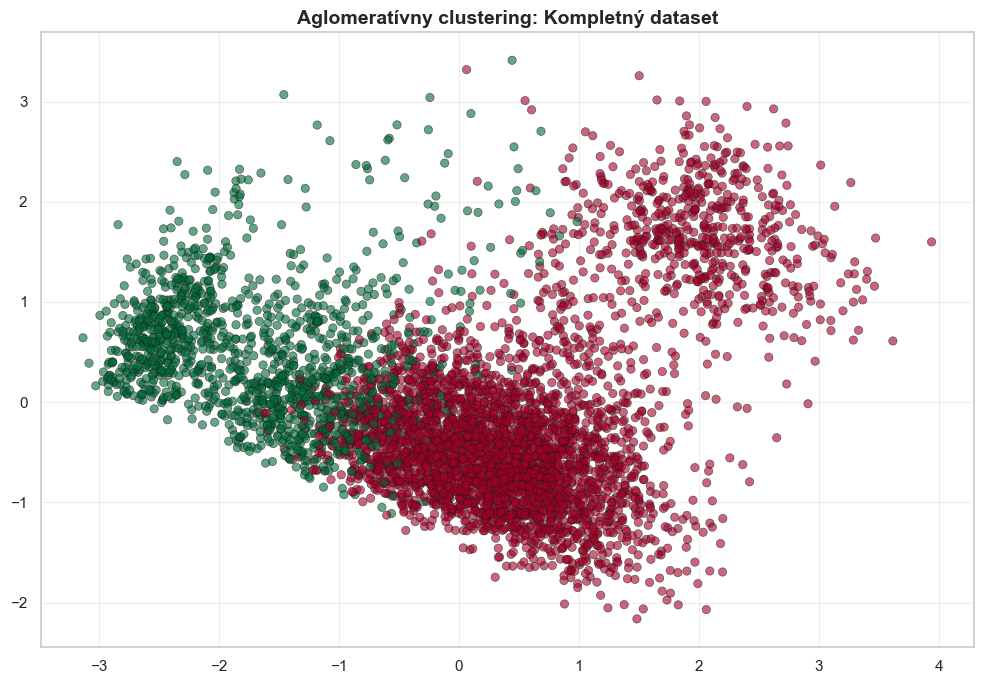

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
cluster,,,,,,,,,,,,,,,,,
0,0.447638,0.131804,0.073106,0.882337,0.510139,0.082178,0.311088,0.065368,0.400747,0.000000,0.000534,0.622732,0.21158,0.002668,0.214248,0.410886,0.175027
1,-1.231826,0.002937,0.001468,0.033774,0.502203,-0.226141,-0.856063,0.002937,0.450073,0.000734,0.014684,0.433921,0.01909,0.497063,0.060206,0.258443,0.097651


In [133]:
visualize_clusters(X_complete, labels_agglo_complete, 
                  "Aglomeratívny clustering: Kompletný dataset")
df_encoded["cluster"] = labels_agglo_complete
cluster_summary = df_encoded.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

- **Cluster 0 – Starší, mierne rizikovejší:**
  - Vyšší vek (age ~0.45) a vyššie hodnoty BMI a glukózy
  - Vyšší výskyt hypertenzie (13%) a srdcových chorôb (7%)
  - Väčšina bola ženatá/vydatá
  - Prevažuje práca v súkromnom sektore
  - Vyšší výskyt mŕtvice (6.5%)

- **Cluster 1 – Mladší, nízke riziko:**
  - Výrazne nižší vek (age ~-1.23), nižšie BMI aj glukóza
  - Prakticky žiadna hypertenzia a srdcové ochorenia
  - Takmer žiadne prípady mŕtvice (0.3%)

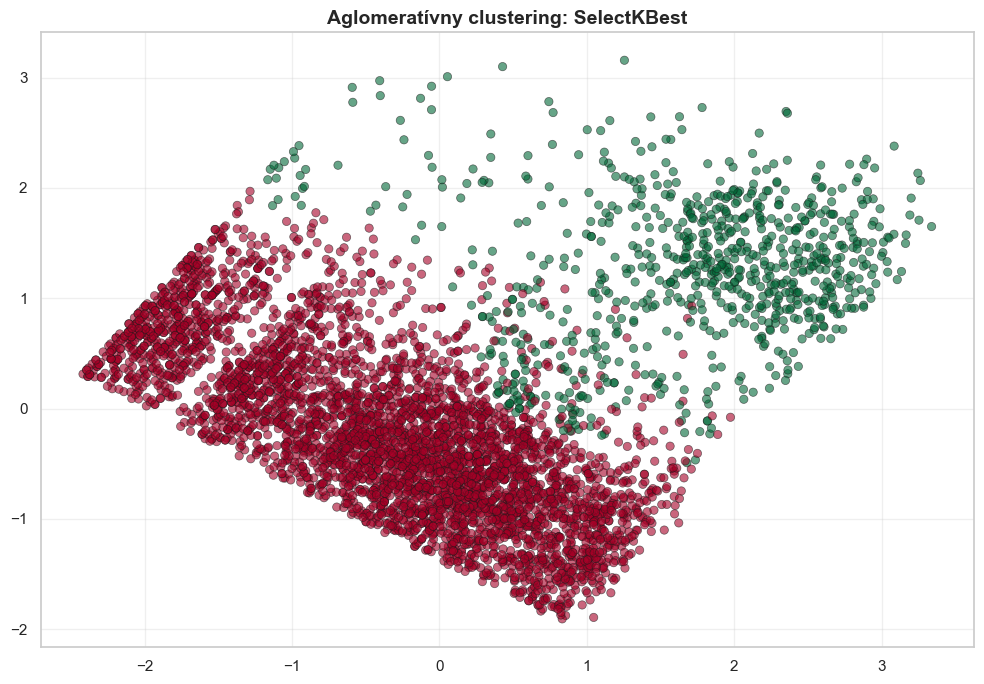

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
cluster,,,,,,,,,,,,,,,,,
0,-0.118809,0.074738,0.038882,0.613970,0.506170,-0.375921,-0.082158,0.036088,0.402095,0.000233,0.004889,0.563679,0.155064,0.153434,0.159721,0.365774,0.152037
1,0.626115,0.217178,0.133742,0.878528,0.517791,1.981081,0.432966,0.115337,0.476074,0.000000,0.001227,0.618405,0.187730,0.034356,0.244172,0.393865,0.166871


In [134]:
visualize_clusters(X_selectkbest, labels_agglo_selectkbest, 
                  "Aglomeratívny clustering: SelectKBest")
df_encoded["cluster"] = labels_agglo_selectkbest
cluster_summary = df_encoded.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

- **Cluster 0 – Mladšia a zdravšia skupina:**
  - Nižší vek (age ~-0.12), nižšia glukóza a BMI
  - Menej prípadov hypertenzie (7%) a srdcových chorôb (3%)
  - Nižší výskyt mŕtvice (~3.6%)
  - Viac slobodných osôb (ever_married ~0.61)
  - Väčší podiel pracujúcich v súkromnom sektore

- **Cluster 1 – Staršia a rizikovejšia skupina:**
  - Vyšší vek (age ~0.63), glukóza aj BMI
  - Vyšší výskyt hypertenzie (21.7%) a srdcových chorôb (13.3%)
  - Viac ženatých/osôb v manželstve (~88%)
  - Mierne vyšší podiel bývalých fajčiarov
  - Vyšší výskyt mŕtvice (~11.5%)

#  **Záverečné zhrnutie najzaujímavejších zistení**

Na základe uskutočnenej analýzy a zhlukovania dát o pacientoch boli identifikované viaceré dôležité poznatky:

- **Vek je dominantným faktorom**: Väčšina prípadov mozgovej príhody sa sústreďuje u starších ľudí, najmä nad 60 rokov. Tento faktor významne ovplyvňoval tvorbu klastrov vo všetkých metódach.

- **Zdravotný stav silne koreluje s rizikom**: Klastre s vyšším výskytom **hypertenzie**, **srdcových ochorení**, zvýšenej hladiny glukózy a vyšším BMI mali zároveň vyšší výskyt mozgovej príhody.

- **Sociálne a behaviorálne faktory zohrávajú úlohu**:
  - **Manželský stav**: Osoby v manželstve mali vyšší vek a častejšie boli v rizikovejšom klastri.
  - **Fajčenie**: Aktuálni a bývalí fajčiari sa častejšie nachádzali v rizikových klastroch.
  - **Typ práce**: Väčšina rizikových osôb pracovala v súkromnom sektore alebo bola samostatne zárobkovo činná, kým mladší patrili do kategórie detí alebo nezamestnaných.

- **Porovnanie metód**:
  - **K-Means** a **Agglomerative Clustering** vytvorili zmysluplné rozdelenia, kde boli jasne rozlíšené rizikové skupiny.
  - **DBSCAN** identifikoval viac klastrov a šumu, čo odhalilo jemnejšie rozdiely, ale nie vždy praktické segmenty.
  - **SelectKBest (chi²)** výber atribútov pomohol zjednodušiť modely bez výraznej straty informačnej hodnoty.